**Basics of R**

In [42]:
a <- 1

In [43]:
a

[1] 1

In [44]:
b <- 3
a + b

[1] 4

In [45]:
c <-2
b/c

[1] 1.5

In [46]:
my_text <- "Joshua"

In [47]:
class(my_text)

[1] "character"

In [48]:
bool <- TRUE
class(bool)

[1] "logical"

In [49]:
die <- 1:6
class(die)

[1] "integer"

In [50]:
die

[1] 1 2 3 4 5 6

In [51]:
die + 1:2

[1] 2 4 4 6 6 8

In [52]:
ls()

[1] "a"       "b"       "bool"    "c"       "deal"    "dice"    "die"    
 [8] "my_text" "roll"    "roll2"

In [53]:
round(3.142)

[1] 3

In [54]:
factorial(4)

[1] 24

In [55]:
round(mean(1:6))

[1] 4

In [56]:
dice <- sample(die, size = 2, replace = TRUE)
dice
sum(dice)

[1] 4 6

[1] 10

In [57]:
roll <- function(){
  die <- 1:6
  dice <- sample(die, size = 2, replace=TRUE)
  dice
  sum(dice)
}

In [58]:
roll()

[1] 7

In [59]:
roll2 <- function(bones){
  dice <- sample(bones, size = 2, replace = TRUE)
  sum (dice)
}

In [60]:
roll2(1:6)

[1] 6

*using packages*

In [61]:
library("ggplot2")

In [62]:
qplot

function (x, y, ..., data, facets = NULL, margins = FALSE, geom = "auto", 
    xlim = c(NA, NA), ylim = c(NA, NA), log = "", main = NULL, 
    xlab = NULL, ylab = NULL, asp = NA, stat = deprecated(), 
    position = deprecated()) 
{
    deprecate_warn0("3.4.0", "qplot()")
    caller_env <- parent.frame()
    if (lifecycle::is_present(stat)) 
        lifecycle::deprecate_stop("2.0.0", "qplot(stat)")
    if (lifecycle::is_present(position)) 
        lifecycle::deprecate_stop("2.0.0", "qplot(position)")
    check_character(geom)
    exprs <- enquos(x = x, y = y, ...)
    is_missing <- vapply(exprs, quo_is_missing, logical(1))
    is_constant <- (!names(exprs) %in% ggplot_global$all_aesthetics) | 
        vapply(exprs, quo_is_call, logical(1), name = "I")
    mapping <- class_mapping(exprs[!is_missing & !is_constant], 
        env = parent.frame())
    consts <- exprs[is_constant]
    aes_names <- names(mapping)
    mapping <- rename_aes(mapping)
    if (is.null(xlab)) {
        if (quo_is_missing(exprs$x)) {
            xlab <- ""
        }
        else {
            xlab <- as_label(exprs$x)
        }
    }
    if (is.null(ylab)) {
        if (quo_is_missing(exprs$y)) {
            ylab <- ""
        }
        else {
            ylab <- as_label(exprs$y)
        }
    }
    if (missing(data)) {
        data <- data_frame0()
        facetvars <- all.vars(facets)
        facetvars <- facetvars[facetvars != "."]
        names(facetvars) <- facetvars
        facetsdf <- as.data.frame(mget(facetvars, envir = caller_env))
        if (nrow(facetsdf)) 
            data <- facetsdf
    }
    if ("auto" %in% geom) {
        if ("sample" %in% aes_names) {
            geom[geom == "auto"] <- "qq"
        }
        else if (missing(y)) {
            x <- eval_tidy(mapping$x, data, caller_env)
            if (is_discrete(x)) {
                geom[geom == "auto"] <- "bar"
            }
            else {
                geom[geom == "auto"] <- "histogram"
            }
            if (is.null(ylab)) 
                ylab <- "count"
        }
        else {
            if (missing(x)) {
                mapping$x <- quo(seq_along(!!mapping$y))
            }
            geom[geom == "auto"] <- "point"
        }
    }
    p <- ggplot(data, mapping, environment = caller_env)
    if (is.null(facets)) {
        p <- p + facet_null()
    }
    else if (is_formula(facets) && length(facets) == 2) {
        p <- p + facet_wrap(facets)
    }
    else {
        p <- p + facet_grid(rows = deparse(facets), margins = margins)
    }
    if (!is.null(main)) 
        p <- p + ggtitle(main)
    for (g in geom) {
        params <- lapply(consts, eval_tidy)
        p <- p + do.call(paste0("geom_", g), params)
    }
    logv <- function(var) var %in% strsplit(log, "")[[1]]
    if (logv("x")) 
        p <- p + scale_x_log10()
    if (logv("y")) 
        p <- p + scale_y_log10()
    if (!is.na(asp)) 
        p <- p + theme(aspect.ratio = asp)
    if (!missing(xlab)) 
        p <- p + xlab(xlab)
    if (!missing(ylab)) 
        p <- p + ylab(ylab)
    if (!missing(xlim) && !all(is.na(xlim))) 
        p <- p + xlim(xlim)
    if (!missing(ylim) && !all(is.na(ylim))) 
        p <- p + ylim(ylim)
    p
}
<bytecode: 0x0000024cb9459af8>
<environment: namespace:ggplot2>

In [63]:
x <- c(-1, -0.8,-0.6,-0.4, -0.2,0,0.2, 0.4, 0.6, 0.8,1)
x

[1] -1.0 -0.8 -0.6 -0.4 -0.2  0.0  0.2  0.4  0.6  0.8  1.0

In [64]:
y <- x ^3
y

[1] -1.000 -0.512 -0.216 -0.064 -0.008  0.000  0.008  0.064  0.216  0.512
[11]  1.000

In [65]:
args(qplot)

function (x, y, ..., data, facets = NULL, margins = FALSE, geom = "auto", 
    xlim = c(NA, NA), ylim = c(NA, NA), log = "", main = NULL, 
    xlab = NULL, ylab = NULL, asp = NA, stat = deprecated(), 
    position = deprecated()) 
NULL

Warning message:
"`qplot()` was deprecated in ggplot2 3.4.0."


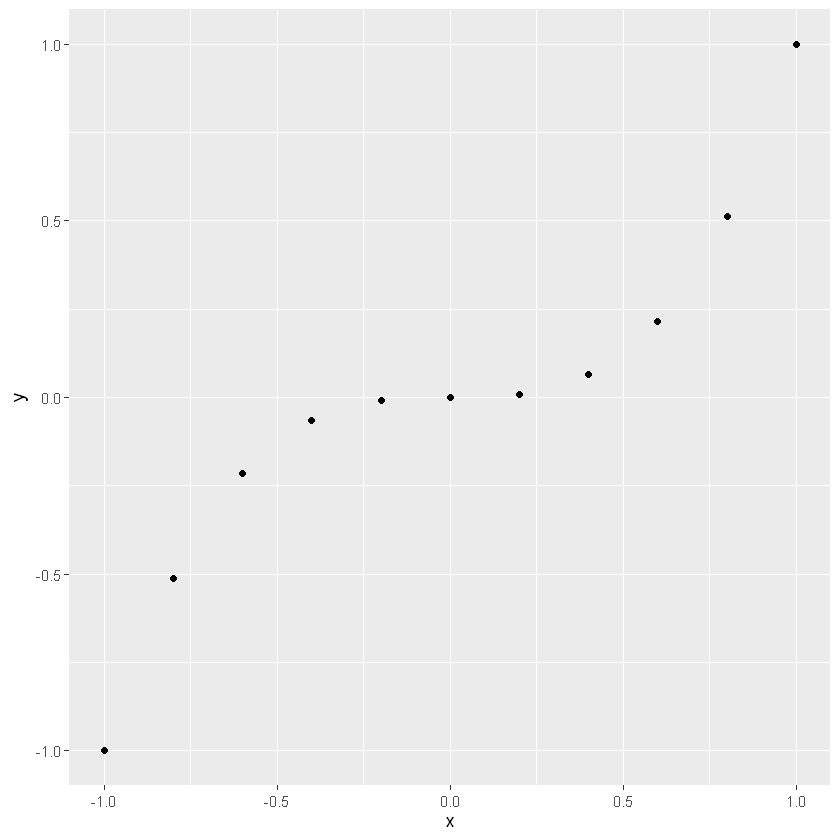

In [66]:
qplot(x,y)

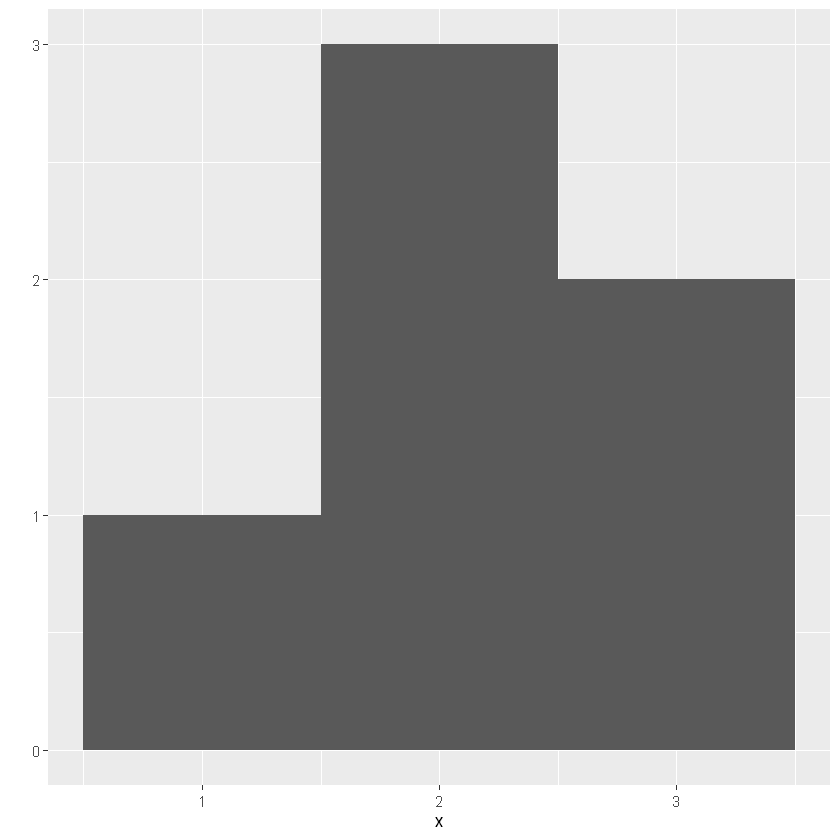

In [67]:
x <- c(1,2,2,2,3,3)
qplot(x, binwidth=1)

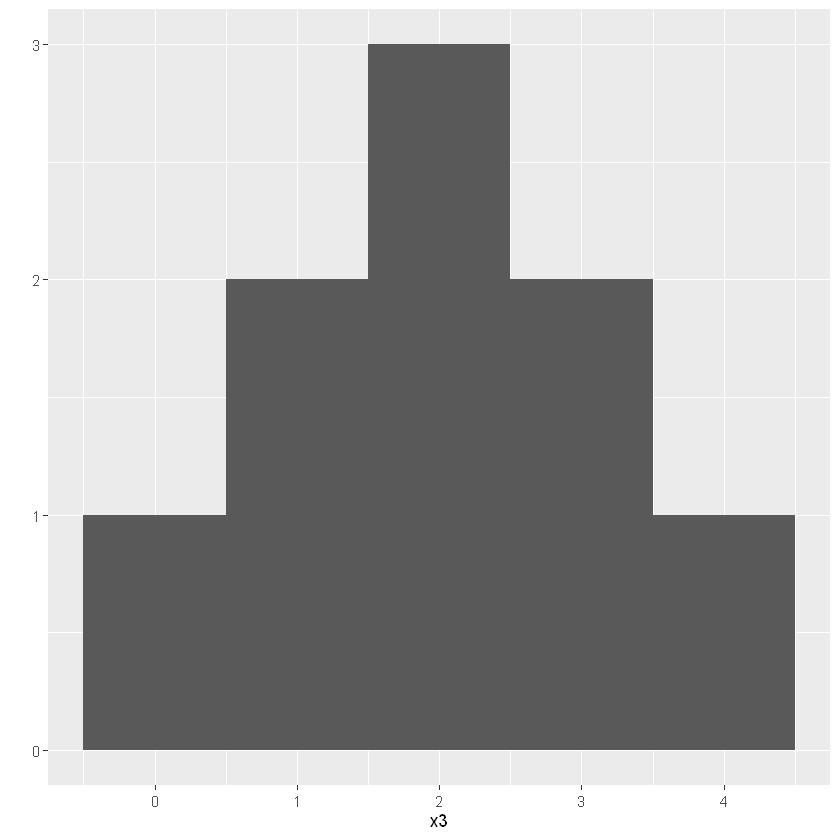

In [68]:
x3 <- c(0,1,1,2,2,2,3,3,4)
qplot(x3, binwidth=1)

In [69]:
replicate(10, roll())

[1]  9 11  6  9  9  2 12  8  8  8

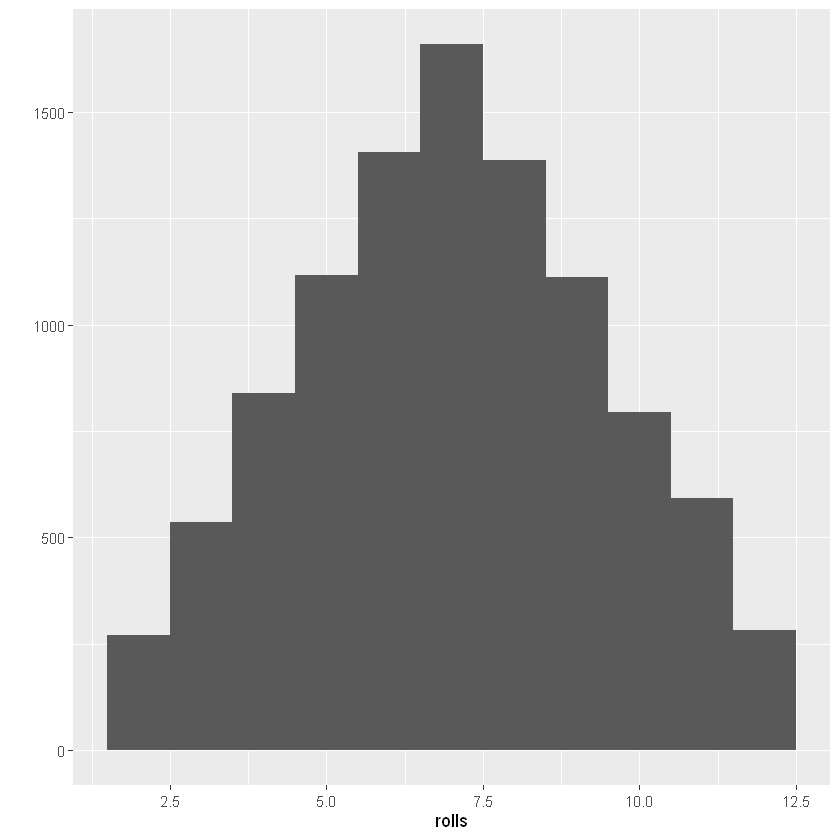

In [70]:
rolls <- replicate(10000, roll())
qplot(rolls, binwidth=1)

In [71]:
roll3 <- function(){
  die <- 1:6
  dice <- sample(die, size = 2, replace = TRUE, prob = c(1/8,1/8,1/8,1/8,1/8,3/8))
  sum(dice)
}

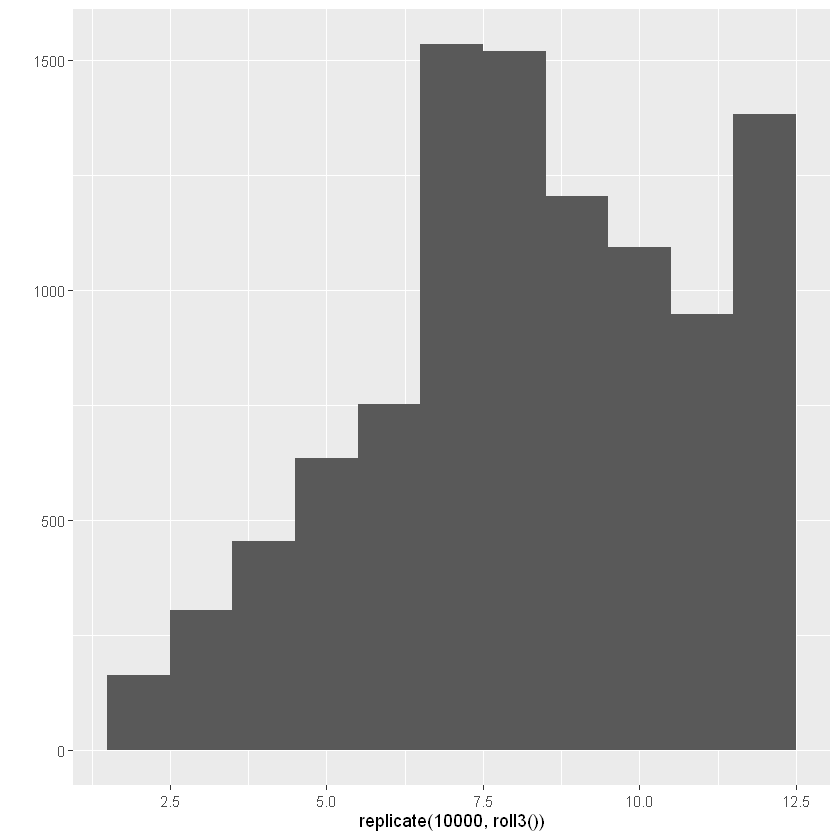

In [72]:
qplot(replicate(10000,roll3()), binwidth=1)

In [73]:
length(dice)

[1] 2

In [74]:
hand = c("ace", "king","queen", "jack", "ten")
typeof(hand)

[1] "character"

In [75]:
attributes(die)

NULL

In [76]:
names(die)

NULL

In [77]:
names(die)<- c("one", "two", "three", "four", "five", "six")
names(die)

[1] "one"   "two"   "three" "four"  "five"  "six"

In [78]:
die+1

one   two three  four  five   six 
    2     3     4     5     6     7

In [79]:
dim(die) <- c(3,2)
die

1,4
2,5
3,6


In [80]:
m <- matrix(die, nrow = 2, byrow = T)
m

1,2,3
4,5,6


In [81]:
ar <- array(c(11:14, 21:24, 31:34), dim = c(2,2,3))
ar <- matrix(ar, nrow = 2)
ar

11,13,21,23,31,33
12,14,22,24,32,34


In [82]:
hand <- c("ace", "king", "queen","jack", "ten", "spades", "spades", "spades", "spades","spades")
card <- matrix(hand, nrow = 5)
card

ace,spades
king,spades
queen,spades
jack,spades
ten,spades


In [83]:
attributes(card)

$dim
[1] 5 2

In [84]:
now = Sys.time()
typeof(now)

[1] "double"

In [85]:
class(now)

[1] "POSIXct" "POSIXt"

In [86]:
gender <- factor(c("male", "female","female", "male"))

attributes(gender)

$levels
[1] "female" "male"  

$class
[1] "factor"

In [87]:
list1 <- list(100:105, "R", list(T,F))
list1

[[1]]
[1] 100 101 102 103 104 105

[[2]]
[1] "R"

[[3]]
[[3]][[1]]
[1] TRUE

[[3]][[2]]
[1] FALSE

In [88]:
df <- data.frame(face=c("ace", "two", "six"), suit = c("clubs", "clubs", "clubs"), value = c(1,2,3))
df

face,suit,value
<chr>,<chr>,<dbl>
ace,clubs,1
two,clubs,2
six,clubs,3


In [89]:
str(df)

'data.frame':	3 obs. of  3 variables:
 $ face : chr  "ace" "two" "six"
 $ suit : chr  "clubs" "clubs" "clubs"
 $ value: num  1 2 3


In [90]:
df <- read.csv("../data/deck.csv", header = TRUE, stringsAsFactors = FALSE)
str(df)

'data.frame':	52 obs. of  3 variables:
 $ face : chr  "king" "queen" "jack" "ten" ...
 $ suit : chr  "spades" "spades" "spades" "spades" ...
 $ value: int  13 12 11 10 9 8 7 6 5 4 ...


In [91]:
head(df)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8


In [92]:
getwd()

[1] "c:/Users/Joshua/work_projects/learningR/code"

In [93]:
write.csv(df, file="../data/cards.csv", row.names=FALSE)

In [94]:
deck <- read.csv("../data/cards.csv", stringsAsFactors = FALSE, header = TRUE)
head(deck)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13
2,queen,spades,12
3,jack,spades,11
4,ten,spades,10
5,nine,spades,9
6,eight,spades,8


In [95]:
deal <- function(cards) {
    cards[1,]
}
deal(deck)

,face,suit,value
,<chr>,<chr>,<int>
1,king,spades,13


In [97]:
shuffle <- function(cards) {
    rand <- sample(1:52, size=52)
    cards[rand,]
}
head(shuffle(deck))

,face,suit,value
,<chr>,<chr>,<int>
6,eight,spades,8
16,jack,clubs,11
12,two,spades,2
29,jack,diamonds,11
18,nine,clubs,9
34,six,diamonds,6


In [99]:
deal(shuffle(deck))

,face,suit,value
,<chr>,<chr>,<int>
45,eight,hearts,8
